In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

print("Libraries loaded ✓")

Libraries loaded ✓


In [5]:
train = pd.read_parquet('/kaggle/input/datasets/montahalassouedd/processed-data-stores-forecasting/train.parquet')
val   = pd.read_parquet('/kaggle/input/datasets/montahalassouedd/processed-data-stores-forecasting/val.parquet')
test  = pd.read_parquet('/kaggle/input/datasets/montahalassouedd/processed-data-stores-forecasting/test.parquet')

# Make sure date is datetime
train['date'] = pd.to_datetime(train['date'])
val['date']   = pd.to_datetime(val['date'])
test['date']  = pd.to_datetime(test['date'])

print(f"Train shape : {train.shape}")
print(f"Val shape   : {val.shape}")
print(f"Test shape  : {test.shape}")
print(f"\nColumns : {train.columns.tolist()}")

Train shape : (2918916, 23)
Val shape   : (53460, 23)
Test shape  : (28512, 23)

Columns : ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'dcoilwtico', 'transactions', 'type_y', 'locale', 'locale_name', 'transferred', 'day_of_week', 'month', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'has_promotion', 'is_holiday']


uestion 1 : What does the sales distribution look like ?

In [6]:
# Use a family that exists
store_id = 1
family   = 'BEVERAGES'

series = train[
    (train['store_nbr'] == store_id) & 
    (train['family'] == family)
].sort_values('date').copy()

print(f"Number of days : {len(series)}")
print(f"Date range     : {series['date'].min()} → {series['date'].max()}")
print(f"\nSales stats :")
print(series['sales'].describe())
print(f"\nZero sales days : {(series['sales'] == 0).sum()}")

Number of days : 1638
Date range     : 2013-01-01 00:00:00 → 2017-06-30 00:00:00

Sales stats :
count    1638.000000
mean     1573.228327
std       726.307447
min         0.000000
25%       965.500000
50%      1520.000000
75%      2193.750000
max      5051.000000
Name: sales, dtype: float64

Zero sales days : 6


** Check distribution


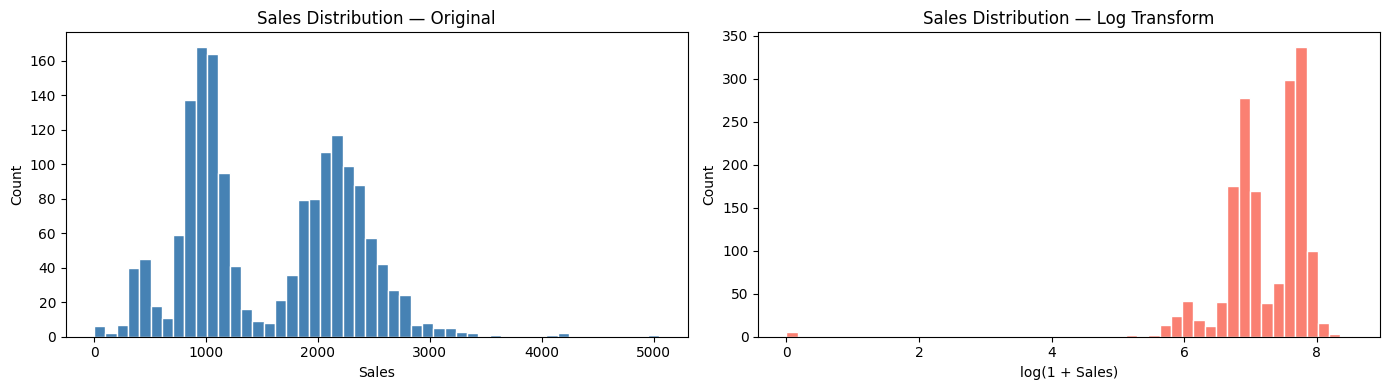

p-value original  : 0.000000
p-value log       : 0.000000
→ Still not normal — we use percentile threshold instead of 3


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Original distribution
axes[0].hist(series['sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution — Original')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Count')

# Log transformed
axes[1].hist(np.log1p(series['sales']), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Sales Distribution — Log Transform')
axes[1].set_xlabel('log(1 + Sales)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Normality test
stat, p_value = stats.normaltest(series['sales'].dropna())
print(f"p-value original  : {p_value:.6f}")

stat, p_value = stats.normaltest(np.log1p(series['sales']).dropna())
print(f"p-value log       : {p_value:.6f}")

if p_value > 0.05:
    print("→ Log transform looks normal ✓ Z-score is valid")
else:
    print("→ Still not normal — we use percentile threshold instead of 3")

Z-score Detection

In [8]:
WINDOW = 30

# Step 1 — Log transform
series['sales_log'] = np.log1p(series['sales'])

# Step 2 — Rolling stats
series['rolling_mean'] = series['sales_log'].rolling(
    window=WINDOW, min_periods=2).mean()
series['rolling_std'] = series['sales_log'].rolling(
    window=WINDOW, min_periods=2).std()

# Step 3 — Z-score
series['z_score'] = (
    (series['sales_log'] - series['rolling_mean']) /
    (series['rolling_std'] + 1e-8)
)

# Step 4 — Threshold (ignore NaN)
THRESHOLD = np.percentile(series['z_score'].abs().dropna(), 95)
print(f"Threshold calculated : {THRESHOLD:.4f}")

# Step 5 — Flag anomalies
series['is_anomaly_zscore'] = series['z_score'].abs() > THRESHOLD

# Summary
n_anomalies = series['is_anomaly_zscore'].sum()
print(f"Anomalies detected : {n_anomalies} / {len(series)}")
print(f"Percentage         : {n_anomalies/len(series)*100:.2f}%")
print(f"\nAnomalous days :")
print(series[series['is_anomaly_zscore']][['date', 'sales', 'z_score']])

Threshold calculated : 2.1677
Anomalies detected : 82 / 1638
Percentage         : 5.01%

Anomalous days :
              date   sales   z_score
71283   2013-02-10   185.0 -3.713827
73065   2013-02-11   172.0 -3.075701
146127  2013-03-24   390.0 -2.327135
155037  2013-03-29   280.0 -2.921223
245919  2013-05-19   354.0 -2.345547
...            ...     ...       ...
2696169 2017-02-26   690.0 -3.061826
2697951 2017-02-27   669.0 -2.647908
2779923 2017-04-14   817.0 -2.838366
2810217 2017-05-01   825.0 -2.228786
2908227 2017-06-25  1070.0 -2.198355

[82 rows x 3 columns]


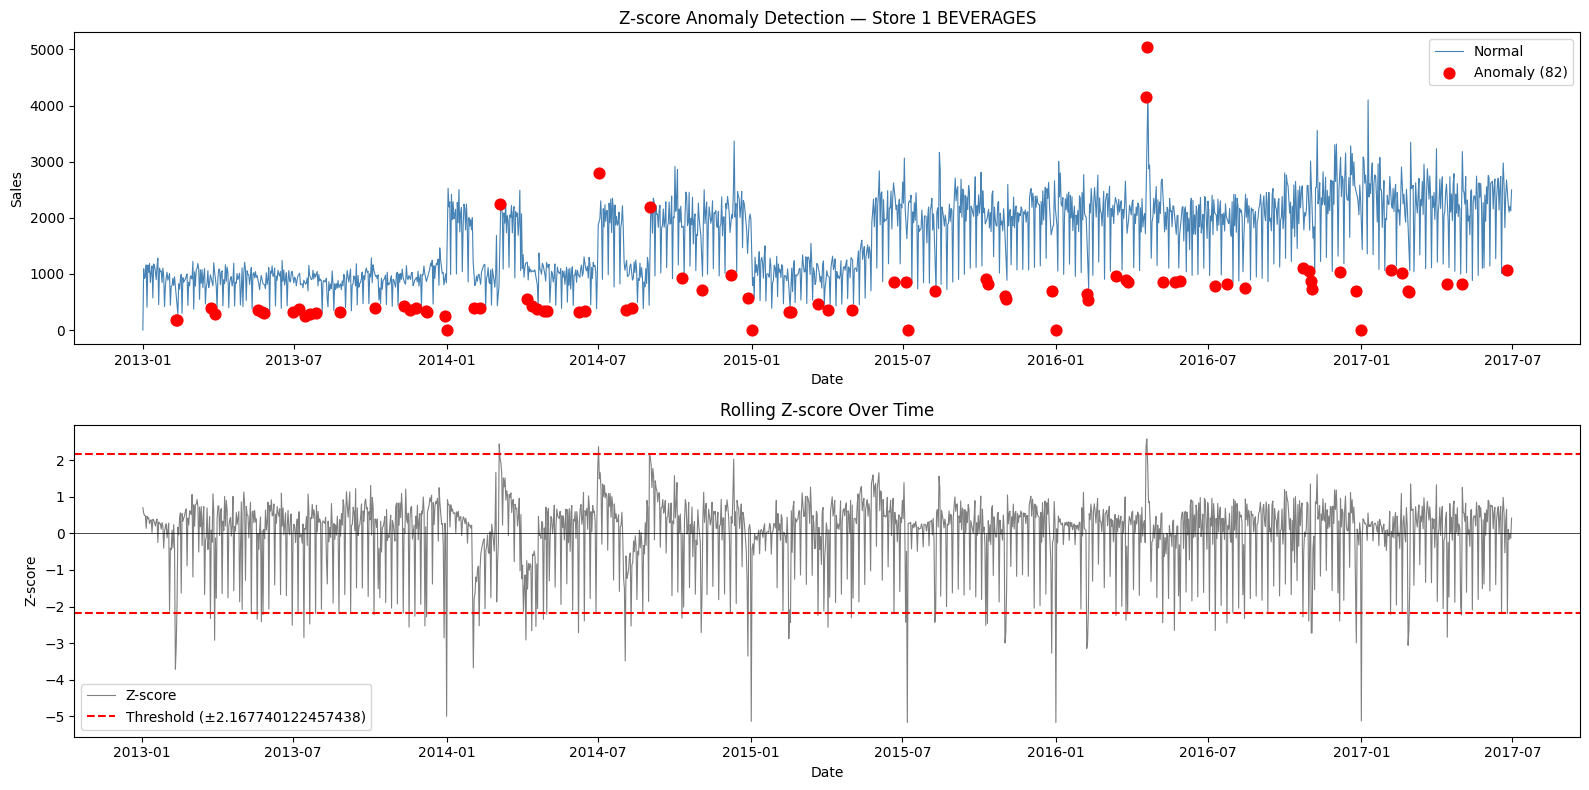

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

normal  = series[~series['is_anomaly_zscore']]
anomaly = series[series['is_anomaly_zscore']]

# Plot 1 — Sales with anomalies
axes[0].plot(normal['date'], normal['sales'],
             color='steelblue', linewidth=0.8, label='Normal')
axes[0].scatter(anomaly['date'], anomaly['sales'],
                color='red', s=60, zorder=5, label=f'Anomaly ({n_anomalies})')
axes[0].set_title(f'Z-score Anomaly Detection — Store {store_id} {family}')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].legend()

# Plot 2 — Z-score over time
axes[1].plot(series['date'], series['z_score'],
             color='gray', linewidth=0.8, label='Z-score')
axes[1].axhline(y=THRESHOLD,  color='red', linestyle='--',
                linewidth=1.5, label=f'Threshold (±{THRESHOLD})')
axes[1].axhline(y=-THRESHOLD, color='red', linestyle='--', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Rolling Z-score Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Z-score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
def zscore_anomaly_detection(df, window=30, threshold=3.0):

    results = []

    for (store, fam), group in df.groupby(['store_nbr', 'family']):
        group = group.sort_values('date').copy()

        # Log transform
        group['sales_log'] = np.log1p(group['sales'])

        # Rolling stats
        group['rolling_mean'] = group['sales_log'].rolling(
            window=window, min_periods=1).mean()
        group['rolling_std']  = group['sales_log'].rolling(
            window=window, min_periods=1).std()

        # Z-score
        group['z_score'] = (
            (group['sales_log'] - group['rolling_mean']) /
            (group['rolling_std'] + 1e-8)
        )

        # Flag
        group['is_anomaly_zscore'] = group['z_score'].abs() > threshold

        results.append(group)

    return pd.concat(results).reset_index(drop=True)


# Run on full train
print("Running Z-score on all store/family combinations...")
train_zscore = zscore_anomaly_detection(train)

# Summary
total     = len(train_zscore)
anomalies = train_zscore['is_anomaly_zscore'].sum()
print(f"Total anomalies : {anomalies} / {total}")
print(f"Percentage      : {anomalies/total*100:.2f}%")

Running Z-score on all store/family combinations...
Total anomalies : 19159 / 2918916
Percentage      : 0.66%


In [11]:
# Save
train_zscore.to_parquet('train_with_zscore.parquet')
print("Z-score saved ✓")

Z-score saved ✓


Isolation Forest

In [12]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib

print("Isolation Forest imports ✓")

Isolation Forest imports ✓


In [19]:
def iforest_anomaly_detection(df, contamination=0.05):

    results = []

    for (store, fam), group in df.groupby(['store_nbr', 'family']):
        group = group.sort_values('date').copy()

        # Features
        X = group[['sales', 'dcoilwtico', 'transactions']].copy()
        X = X.fillna(X.median())

        # Scale
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Train
        model = IsolationForest(
            n_estimators=100,
            contamination=contamination,
            random_state=42
        )
        model.fit(X_scaled)

        # Predict
        group['iforest_prediction'] = model.predict(X_scaled)
        group['iforest_score']      = model.score_samples(X_scaled)
        group['is_anomaly_iforest'] = group['iforest_prediction'] == -1

        results.append(group)

    return pd.concat(results).reset_index(drop=True)


print("Running Isolation Forest on all store/family combinations...")
train_iforest = iforest_anomaly_detection(train)

total     = len(train_iforest)
anomalies = train_iforest['is_anomaly_iforest'].sum()
print(f"Total anomalies : {anomalies} / {total}")
print(f"Percentage      : {anomalies/total*100:.2f}%")

Running Isolation Forest on all store/family combinations...
Total anomalies : 146104 / 2918916
Percentage      : 5.01%


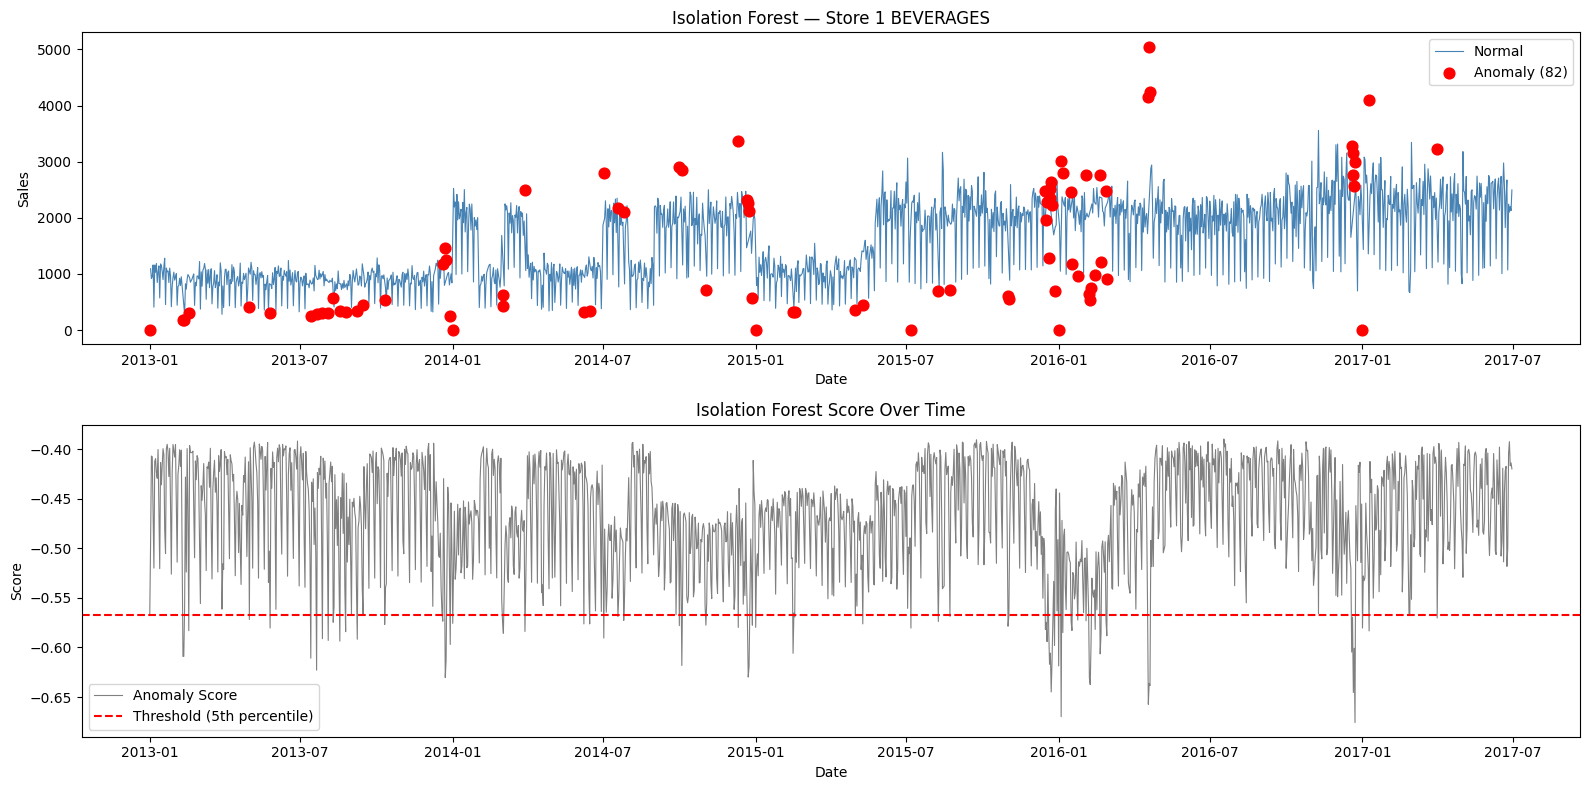

In [20]:
# Visualise sur Store 1, BEVERAGES comme avant
store_id = 1
family   = 'BEVERAGES'

series_if = train_iforest[
    (train_iforest['store_nbr'] == store_id) &
    (train_iforest['family'] == family)
].sort_values('date')

normal  = series_if[~series_if['is_anomaly_iforest']]
anomaly = series_if[series_if['is_anomaly_iforest']]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Plot 1 — Sales avec anomalies
axes[0].plot(normal['date'], normal['sales'],
             color='steelblue', linewidth=0.8, label='Normal')
axes[0].scatter(anomaly['date'], anomaly['sales'],
                color='red', s=60, zorder=5,
                label=f'Anomaly ({len(anomaly)})')
axes[0].set_title(f'Isolation Forest — Store {store_id} {family}')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].legend()

# Plot 2 — Anomaly score over time
axes[1].plot(series_if['date'], series_if['iforest_score'],
             color='gray', linewidth=0.8, label='Anomaly Score')
axes[1].axhline(y=series_if['iforest_score'].quantile(0.05),
                color='red', linestyle='--',
                linewidth=1.5, label='Threshold (5th percentile)')
axes[1].set_title('Isolation Forest Score Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Vérifie GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

Device : cuda


In [23]:
# On travaille sur une série pour commencer
# Même approche qu'avant — Store 1 BEVERAGES
store_id = 1
family   = 'BEVERAGES'

FEATURES = ['sales', 'dcoilwtico', 'transactions']
WINDOW   = 30  # 30 jours par séquence

# Filtre la série
series_ae = train[
    (train['store_nbr'] == store_id) &
    (train['family'] == family)
].sort_values('date').copy()

# Remplis NaN
series_ae[FEATURES] = series_ae[FEATURES].fillna(series_ae[FEATURES].median())

print(f"Série shape : {series_ae.shape}")
print(series_ae[FEATURES].describe())

Série shape : (1638, 23)
             sales   dcoilwtico  transactions
count  1638.000000  1638.000000   1638.000000
mean   1573.228327    68.503187   1525.689255
std     726.307447    25.796870    502.952490
min       0.000000    26.190000     10.000000
25%     965.500000    46.607500   1327.250000
50%    1520.000000    53.965000   1746.000000
75%    2193.750000    95.922500   1831.750000
max    5051.000000   110.620000   3023.000000


In [24]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler → ramène tout entre 0 et 1
# Mieux que StandardScaler pour les autoencoders
scaler_ae = MinMaxScaler()

data_scaled = scaler_ae.fit_transform(series_ae[FEATURES])

print(f"Scaled shape : {data_scaled.shape}")
print(f"Min : {data_scaled.min():.4f}")
print(f"Max : {data_scaled.max():.4f}")

Scaled shape : (1638, 3)
Min : 0.0000
Max : 1.0000


In [25]:
def create_sequences(data, window=30):
    sequences = []
    for i in range(len(data) - window + 1):
        sequences.append(data[i : i + window])
    return np.array(sequences)

sequences = create_sequences(data_scaled, window=WINDOW)

print(f"Sequences shape : {sequences.shape}")
# (nombre de séquences, window=30, features=3)

Sequences shape : (1609, 30, 3)


In [26]:
# 80% pour entraîner, 20% pour calibrer le threshold
split = int(len(sequences) * 0.8)

X_train_ae = sequences[:split]
X_val_ae   = sequences[split:]

print(f"Train sequences : {X_train_ae.shape}")
print(f"Val sequences   : {X_val_ae.shape}")

# Convertit en tenseurs PyTorch
X_train_tensor = torch.FloatTensor(X_train_ae).to(device)
X_val_tensor   = torch.FloatTensor(X_val_ae).to(device)

# DataLoader
train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=32,
    shuffle=True
)

print("Tensors ready ✓")

Train sequences : (1287, 30, 3)
Val sequences   : (322, 30, 3)
Tensors ready ✓


In [28]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size, num_layers=1):
        super(LSTMAutoencoder, self).__init__()
        
        # ENCODER — comprime la séquence
        self.encoder = nn.LSTM(
            input_size  = input_size,   # 3 features
            hidden_size = hidden_size,  # 64 units
            num_layers  = num_layers,
            batch_first = True
        )
        
        # BOTTLENECK — résumé compact
        self.encoder_fc = nn.Linear(hidden_size, latent_size)
        
        # DECODER — reconstruit la séquence
        self.decoder_fc = nn.Linear(latent_size, hidden_size)
        
        self.decoder = nn.LSTM(
            input_size  = hidden_size,  # 64 units
            hidden_size = input_size,   # retourne à 3 features
            num_layers  = num_layers,
            batch_first = True
        )
    
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        # ENCODE
        _, (hidden, _) = self.encoder(x)
        # hidden shape : (1, batch, hidden_size)
        hidden = hidden.squeeze(0)  # (batch, hidden_size)
        
        # BOTTLENECK
        latent = self.encoder_fc(hidden)  # (batch, latent_size)
        
        # DECODE
        hidden_dec = self.decoder_fc(latent)  # (batch, hidden_size)
        
        # Répète le latent vector pour chaque timestep
        hidden_dec = hidden_dec.unsqueeze(1).repeat(1, seq_len, 1)
        # (batch, seq_len, hidden_size)
        
        # Reconstruit
        output, _ = self.decoder(hidden_dec)
        # output shape : (batch, seq_len, input_size=3)
        
        return output


# Paramètres
INPUT_SIZE  = 3   # sales, oil, transactions
HIDDEN_SIZE = 64  # taille encoder/decoder
LATENT_SIZE = 16  # bottleneck — résumé compact (entre 1/4 et 1/2 de hidden)
NUM_LAYERS  = 1

model = LSTMAutoencoder(
    input_size  = INPUT_SIZE,
    hidden_size = HIDDEN_SIZE,
    latent_size = LATENT_SIZE,
    num_layers  = NUM_LAYERS
).to(device)

print(model)
print(f"\nTotal parameters : {sum(p.numel() for p in model.parameters()):,}")

LSTMAutoencoder(
  (encoder): LSTM(3, 64, batch_first=True)
  (encoder_fc): Linear(in_features=64, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=64, bias=True)
  (decoder): LSTM(64, 3, batch_first=True)
)

Total parameters : 20,620


In [29]:
EPOCHS    = 50
LR        = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses = []
val_losses   = []

print("Training LSTM Autoencoder...")

for epoch in range(EPOCHS):
    
    # Training
    model.train()
    batch_losses = []
    
    for (batch,) in train_loader:
        optimizer.zero_grad()
        output = model(batch)
        loss   = criterion(output, batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val_tensor)
        val_loss   = criterion(val_output, X_val_tensor).item()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss : {train_loss:.6f} | Val Loss : {val_loss:.6f}")

print("\nTraining done ✓")

Training LSTM Autoencoder...
Epoch 10/50 | Train Loss : 0.013252 | Val Loss : 0.015445
Epoch 20/50 | Train Loss : 0.012530 | Val Loss : 0.014262
Epoch 30/50 | Train Loss : 0.012432 | Val Loss : 0.014127
Epoch 40/50 | Train Loss : 0.012358 | Val Loss : 0.014028
Epoch 50/50 | Train Loss : 0.012356 | Val Loss : 0.013890

Training done ✓


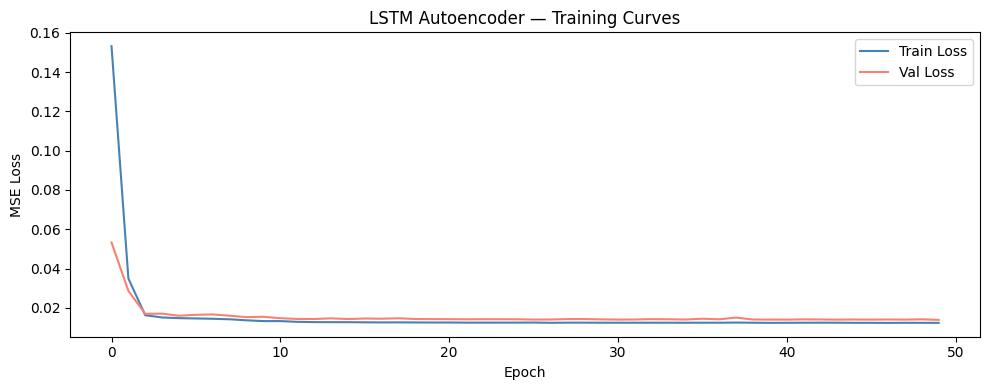

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='salmon')
plt.title('LSTM Autoencoder — Training Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
model.eval()

with torch.no_grad():
    # Reconstruction sur val set
    val_reconstructed = model(X_val_tensor)
    
    # Erreur par séquence (MAE sur chaque séquence)
    val_errors = torch.mean(
        torch.abs(X_val_tensor - val_reconstructed),
        dim=(1, 2)
    ).cpu().numpy()

print(f"Val errors shape : {val_errors.shape}")
print(f"Mean error : {val_errors.mean():.6f}")
print(f"Max error  : {val_errors.max():.6f}")
print(f"95th percentile : {np.percentile(val_errors, 95):.6f}")

Val errors shape : (322,)
Mean error : 0.080143
Max error  : 0.104514
95th percentile : 0.095136


Threshold : 0.095136


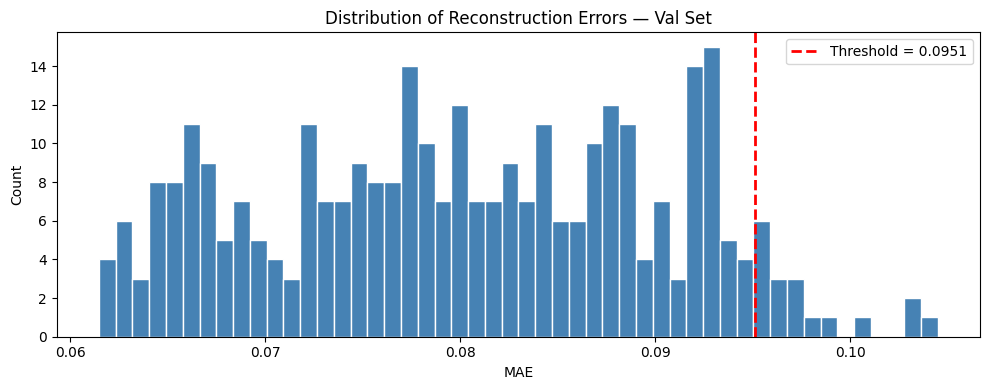

In [32]:
# Threshold = 95e percentile des erreurs sur val set
THRESHOLD_AE = np.percentile(val_errors, 95)
print(f"Threshold : {THRESHOLD_AE:.6f}")

# Plot distribution des erreurs
plt.figure(figsize=(10, 4))
plt.hist(val_errors, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=THRESHOLD_AE, color='red', linestyle='--',
            linewidth=2, label=f'Threshold = {THRESHOLD_AE:.4f}')
plt.title('Distribution of Reconstruction Errors — Val Set')
plt.xlabel('MAE')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
model.eval()

with torch.no_grad():
    # Reconstruction sur toute la série
    all_sequences = torch.FloatTensor(sequences).to(device)
    all_reconstructed = model(all_sequences)
    
    # Erreur par séquence
    all_errors = torch.mean(
        torch.abs(all_sequences - all_reconstructed),
        dim=(1, 2)
    ).cpu().numpy()

# Chaque séquence correspond au dernier jour de la fenêtre
# On aligne avec les dates
series_ae = series_ae.iloc[WINDOW-1:].copy().reset_index(drop=True)
series_ae['reconstruction_error'] = all_errors
series_ae['is_anomaly_lstm']      = all_errors > THRESHOLD_AE

# Summary
n_anomalies = series_ae['is_anomaly_lstm'].sum()
print(f"Anomalies detected : {n_anomalies} / {len(series_ae)}")
print(f"Percentage         : {n_anomalies/len(series_ae)*100:.2f}%")

Anomalies detected : 85 / 1609
Percentage         : 5.28%


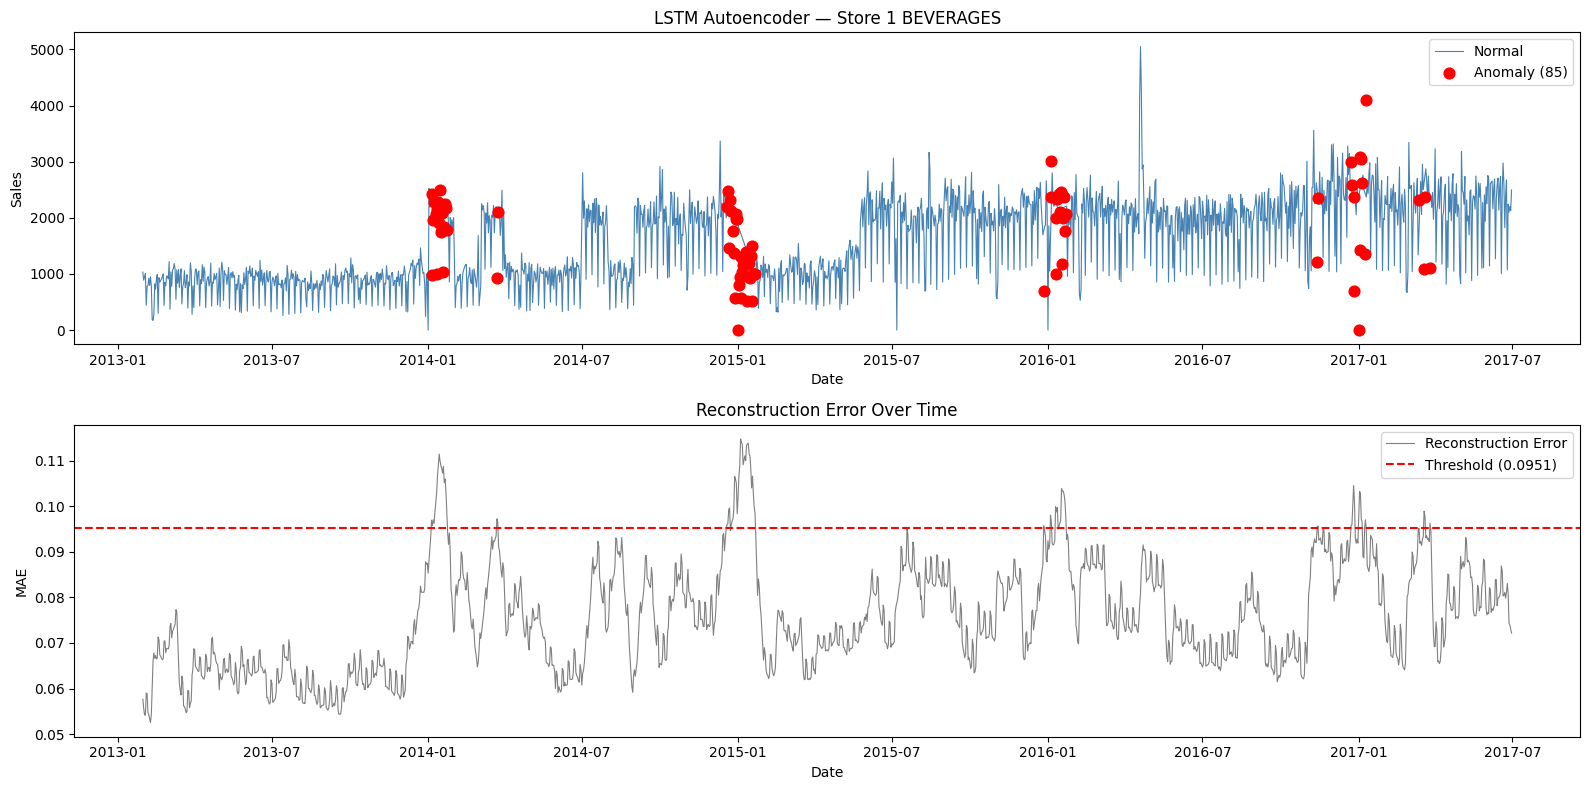

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

normal  = series_ae[~series_ae['is_anomaly_lstm']]
anomaly = series_ae[series_ae['is_anomaly_lstm']]

# Plot 1 — Sales avec anomalies
axes[0].plot(normal['date'], normal['sales'],
             color='steelblue', linewidth=0.8, label='Normal')
axes[0].scatter(anomaly['date'], anomaly['sales'],
                color='red', s=60, zorder=5,
                label=f'Anomaly ({n_anomalies})')
axes[0].set_title(f'LSTM Autoencoder — Store {store_id} {family}')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales')
axes[0].legend()

# Plot 2 — Reconstruction error
axes[1].plot(series_ae['date'], series_ae['reconstruction_error'],
             color='gray', linewidth=0.8, label='Reconstruction Error')
axes[1].axhline(y=THRESHOLD_AE, color='red', linestyle='--',
                linewidth=1.5, label=f'Threshold ({THRESHOLD_AE:.4f})')
axes[1].set_title('Reconstruction Error Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()